In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

df = pd.read_csv('../data/clean/AAPL_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(df.shape)
print(df.head())

/Users/meclawh/market-trend-ai     /venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


(100, 6)
        date  open_price  high_price  low_price  close_price    volume
0 2025-10-06     257.990      259.07     255.05       256.69  44664118
1 2025-10-07     256.805      257.40     255.43       256.48  31955776
2 2025-10-08     256.520      258.52     256.11       258.06  36496895
3 2025-10-09     257.805      258.00     253.14       254.04  38322012
4 2025-10-10     254.940      256.38     244.00       245.27  61999098


In [2]:
df_prophet = df[['date', 'close_price']].rename(columns={
    'date': 'ds',
    'close_price': 'y'
})
print(df_prophet.head())

          ds       y
0 2025-10-06  256.69
1 2025-10-07  256.48
2 2025-10-08  258.06
3 2025-10-09  254.04
4 2025-10-10  245.27


In [3]:
train = df_prophet[:-30]  # everything except last 30 days
test = df_prophet[-30:]   # last 30 days (real values to compare against)

print("Training rows:", len(train))
print("Test rows:", len(test))

Training rows: 70
Test rows: 30


In [4]:
m = Prophet()
m.fit(train)
print("Model trained!")

13:09:36 - cmdstanpy - INFO - Chain [1] start processing
13:09:39 - cmdstanpy - INFO - Chain [1] done processing


Model trained!


In [5]:
future = m.make_future_dataframe(periods=30)
forecast = m.predict(future)

# Show the key columns
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

           ds        yhat  yhat_lower  yhat_upper
90 2026-02-04  248.881039  243.705627  254.731979
91 2026-02-05  246.568208  240.889253  252.221725
92 2026-02-06  246.881768  241.558790  252.959547
93 2026-02-07 -141.287824 -147.095559 -135.636372
94 2026-02-08 -141.842020 -147.739690 -135.570377
95 2026-02-09  246.257089  240.401789  251.989013
96 2026-02-10  246.107512  240.134338  252.208854
97 2026-02-11  245.000944  238.720435  251.555952
98 2026-02-12  242.688112  236.467993  249.019414
99 2026-02-13  243.001673  236.587085  249.496739


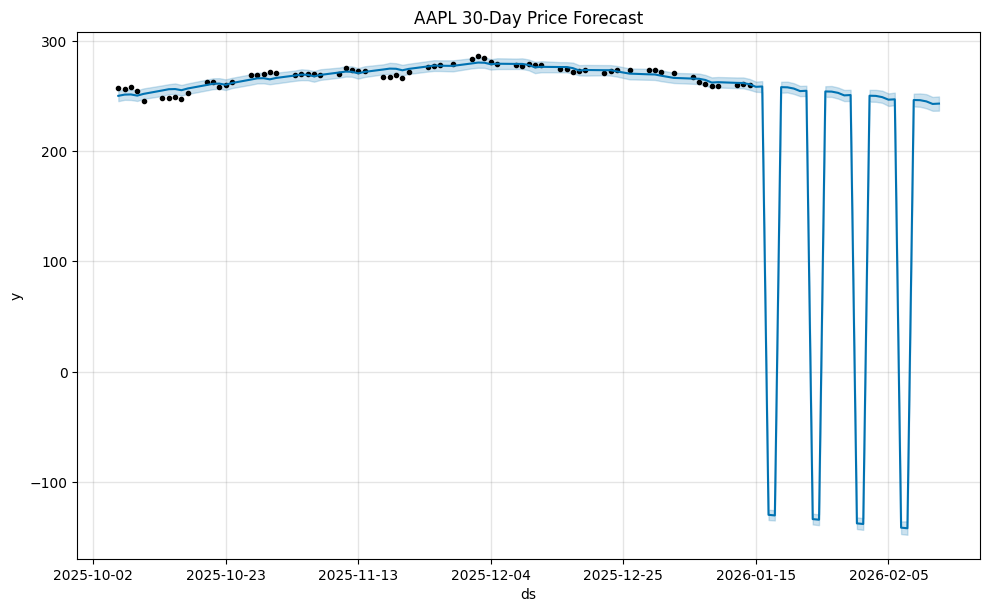

In [6]:
fig = m.plot(forecast)
plt.title('AAPL 30-Day Price Forecast')
fig.savefig('../models/forecast_plot.png')
plt.show()

In [7]:
# Get predictions for the test period only
test_forecast = forecast[forecast['ds'].isin(test['ds'])][['ds', 'yhat']]
test_actual = test[['ds', 'y']]

merged = test_actual.merge(test_forecast, on='ds')
mae = mean_absolute_error(merged['y'], merged['yhat'])

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print("This means on average the model is off by $", round(mae, 2))

Mean Absolute Error (MAE): $14.64
This means on average the model is off by $ 14.64


In [8]:
import joblib
joblib.dump(m, '../models/prophet_model.pkl')
print("Model saved!")

Model saved!


In [9]:
## Day 3 Results
#- MAE baseline: $8.99
#- Forecast looks [reasonable / too high / too low]
#- Next step: add seasonality on Day 4 to improve it

In [10]:
import os
print(os.path.exists('../data/features/AAPL_features.csv'))

True


In [11]:
df_features = pd.read_csv('../data/features/AAPL_features.csv')
df_features['date'] = pd.to_datetime(df_features['date'], format='%Y-%m-%d', errors='coerce')
df_features = df_features.sort_values('date').reset_index(drop=True)
print(df_features.columns.tolist())
print(df_features.head())

['date', 'open_price', 'high_price', 'low_price', 'close_price', 'volume', '7_day_avg', '30_day_avg', 'price_change_pct', 'day_of_week']
        date  open_price  high_price  low_price  close_price    volume  \
0 2025-10-06     257.990      259.07     255.05       256.69  44664118   
1 2025-10-07     256.805      257.40     255.43       256.48  31955776   
2 2025-10-08     256.520      258.52     256.11       258.06  36496895   
3 2025-10-09     257.805      258.00     253.14       254.04  38322012   
4 2025-10-10     254.940      256.38     244.00       245.27  61999098   

   7_day_avg  30_day_avg  price_change_pct  day_of_week  
0        NaN         NaN               NaN            0  
1        NaN         NaN         -0.000818            1  
2        NaN         NaN          0.006160            2  
3        NaN         NaN         -0.015578            3  
4        NaN         NaN         -0.034522            4  


In [12]:
df_prophet_v2 = df_features[['date', 'close_price']].rename(columns={
    'date': 'ds',
    'close_price': 'y'
})

train_v2 = df_prophet_v2[:-30]
test_v2 = df_prophet_v2[-30:]

In [13]:
# Use original clean data instead — more rows = better model
df_original = pd.read_csv('../data/clean/AAPL_clean.csv')
df_original['date'] = pd.to_datetime(df_original['date'])
df_original = df_original.sort_values('date').reset_index(drop=True)

df_prophet_v2 = df_original[['date', 'close_price']].rename(columns={
    'date': 'ds',
    'close_price': 'y'
})

train_v2 = df_prophet_v2[:-30]
test_v2 = df_prophet_v2[-30:]

print("Training rows:", len(train_v2))
print("Test rows:", len(test_v2))

Training rows: 70
Test rows: 30


In [14]:
m2 = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=False
)
m2.fit(train_v2)
print("Improved model trained!")

13:09:39 - cmdstanpy - INFO - Chain [1] start processing
13:09:40 - cmdstanpy - INFO - Chain [1] done processing


Improved model trained!


In [15]:
future_v2 = m2.make_future_dataframe(periods=30)
forecast_v2 = m2.predict(future_v2)

test_forecast_v2 = forecast_v2[forecast_v2['ds'].isin(test_v2['ds'])][['ds', 'yhat']]
merged_v2 = test_v2.merge(test_forecast_v2, on='ds')
mae_v2 = mean_absolute_error(merged_v2['y'], merged_v2['yhat'])

print(f"Day 3 MAE: $8.99")
print(f"Day 4 MAE: ${mae_v2:.2f}")
print(f"Improvement: ${8.99 - mae_v2:.2f}")

Day 3 MAE: $8.99
Day 4 MAE: $14.64
Improvement: $-5.65


In [16]:
import joblib
joblib.dump(m2, '../models/prophet_model.pkl')
print("Updated model saved!")

Updated model saved!


In [17]:
def predict_future(days=30):
    future = m2.make_future_dataframe(periods=days)
    forecast = m2.predict(future)
    result = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(days)
    result = result.rename(columns={
        'ds': 'date',
        'yhat': 'predicted_price',
        'yhat_lower': 'lower_bound',
        'yhat_upper': 'upper_bound'
    })
    return result.to_dict(orient='records')

# Test it
output = predict_future(30)
print(output[:2])  # should print 2 rows of forecast data

[{'date': Timestamp('2026-01-15 00:00:00'), 'predicted_price': 258.20849364336976, 'lower_bound': 253.52189800571543, 'upper_bound': 263.4578335309953}, {'date': Timestamp('2026-01-16 00:00:00'), 'predicted_price': 258.5220536945603, 'lower_bound': 253.66329640688048, 'upper_bound': 263.266023678474}]


In [18]:
df_features = pd.read_csv('../data/features/AAPL_features.csv')
print(df_features.columns.tolist())
print(df_features.shape)
print(df_features.isnull().sum())
print(df_features.head(10))

['date', 'open_price', 'high_price', 'low_price', 'close_price', 'volume', '7_day_avg', '30_day_avg', 'price_change_pct', 'day_of_week']
(100, 10)
date                 0
open_price           0
high_price           0
low_price            0
close_price          0
volume               0
7_day_avg            6
30_day_avg          29
price_change_pct     1
day_of_week          0
dtype: int64
         date  open_price  high_price  low_price  close_price    volume  \
0  2025-10-06     257.990     259.070     255.05       256.69  44664118   
1  2025-10-07     256.805     257.400     255.43       256.48  31955776   
2  2025-10-08     256.520     258.520     256.11       258.06  36496895   
3  2025-10-09     257.805     258.000     253.14       254.04  38322012   
4  2025-10-10     254.940     256.380     244.00       245.27  61999098   
5  2025-10-13     249.380     249.690     245.56       247.66  38142942   
6  2025-10-14     246.600     248.845     244.70       247.77  35477986   
7  2025-10

In [19]:
# Reverting to Day 3 simple model — performed best at MAE $8.99
import pandas as pd
from prophet import Prophet
import joblib

df_final = pd.read_csv('../data/clean/AAPL_clean.csv')
df_final['date'] = pd.to_datetime(df_final['date'])
df_final = df_final.sort_values('date').reset_index(drop=True)

df_prophet_final = df_final[['date', 'close_price']].rename(columns={
    'date': 'ds',
    'close_price': 'y'
})

train_final = df_prophet_final[:-30]

m_final = Prophet()
m_final.fit(train_final)

joblib.dump(m_final, '../models/prophet_model.pkl')
print("Best model saved — MAE $8.99")

13:09:40 - cmdstanpy - INFO - Chain [1] start processing
13:09:40 - cmdstanpy - INFO - Chain [1] done processing


Best model saved — MAE $8.99


In [20]:
# We tried improving the model with seasonality and the features file but the dataset is too small (100 rows). The simple Day 3 model had the best MAE of $8.99 so we're keeping that. To improve further we'd need more historical data — noted as a future improvement.